Question 1 

In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def norm_dist(x, mu, std):
    f = (2*np.pi*(std**2))**-0.5 * (np.exp(-((x - mu)**2)/ (2*std**2)))
    return f

In [60]:
def plot_norm_dist(mu,std):
    x = np.linspace(mu-3*std, mu+3*std, 50)
    y = [norm_dist(x, mu, std) for x in x]
    plt.plot(x,y)

In [61]:
norm_dist(2, 0, 0.2)

3.8472993133532365e-22

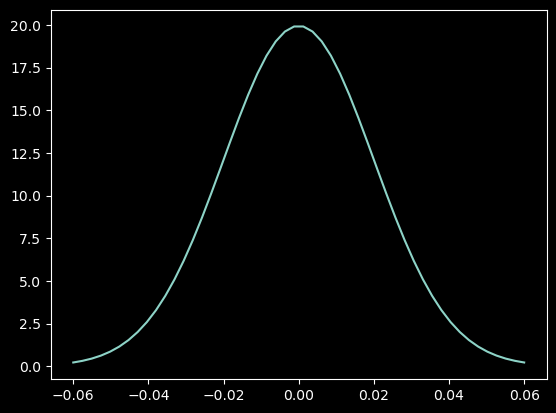

In [62]:
plot_norm_dist(0,(0.02))

1. Conditional probability: suppose that if ω = 1, then y has a normal distribution with
mean 1 and standard deviation σ, and if ω = 2, then y has a normal distribution with
mean 2 and standard deviation σ. Also, suppose Pr(ω = 1) = 0.5 and Pr(ω = 2) = 0.5.
(a) For σ = 2, write the formula for the marginal probability density for y and sketch it.
(b) What is Pr(ω = 1|y = 1), again supposing σ = 2?
(c) Describe how the posterior density of ω changes in shape as σ is increased and as it is
decreased.

In [63]:
p_y = 0.5*norm_dist(1, mu=1, std = 2) + 0.5*norm_dist(x=1, mu = 2, std = 2)
(0.5*norm_dist(1, mu = 1, std = 2)) / p_y

0.5312093733737563

 As σ → ∞, the posterior density for θ approaches the prior (the data contain no information):
Pr(θ = 1|y = 1) → 1
2
. As σ → 0, the posterior density for θ becomes concentrated at 1: Pr(θ =1|y = 1) → 1.


Conditional means and variances: show that (1.8) and (1.9) hold if u is a vector

Chapter 2.

girls born = 241945 
boys born = 251527

p(theta= 0.5)
p(prob girl born > 0.5| y= 241945, n = 241945+ 251527)


p(y|theta>=0.5) / p(y)

What you're working with
Laplace is doing Bayesian inference on a binomial proportion. You have:

A likelihood: each birth is female with probability ω
A prior: ω ~ Uniform(0, 1) — Laplace's "principle of insufficient reason"
Data: y girls out of n total births

The key question to ask yourself first
With a Uniform(0,1) prior and a Binomial likelihood, what is the posterior distribution of ω? There's a well-known conjugate family here — do you know what it is?

The principle of indifference (also called principle of insufficient reason) is a rule for assigning epistemic probabilities. The principle of indifference states that in the absence of any relevant evidence, agents should distribute their credence (or "degrees of belief") equally among all the possible outcomes under consideration.[1] It can be viewed as an application of the principle of parsimony and as a special case of the principle of maximum entropy. In Bayesian probability, this is the simplest non-informative prior.

In mathematics, a monotonic function (or monotone function) is a function between ordered sets that preserves or reverses the given order.[1][2][3] This concept first arose in calculus, and was later generalized to the more abstract setting of order theory.

θ2
θ1
( n C y)ω^^y(1 − ω)^^n-ydω

the maximum at theta= y/n   intuitively, y/n is what we SEE in the data, so would make sense to be the max.

log[ωy(1−ω)n−y]=ylogω+(n−y)log(1−ω)
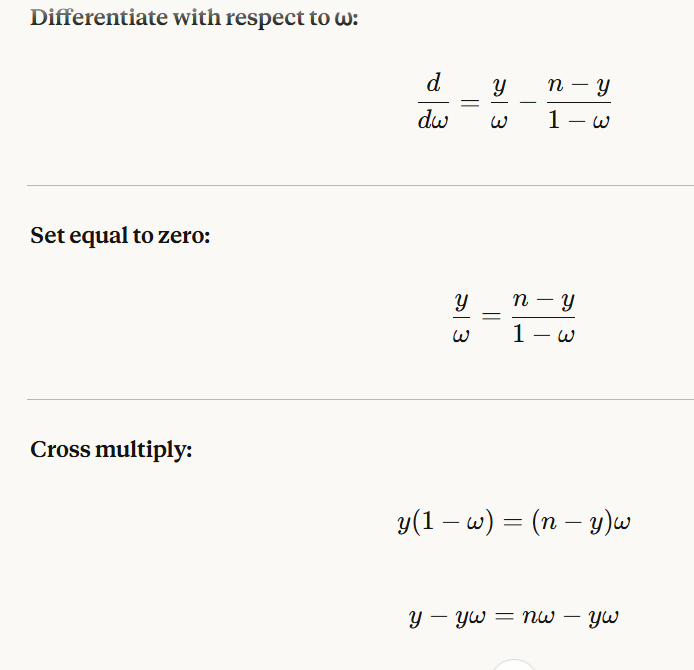

And this ω^=y/n\hat{\omega} = y/n
ω^=y/n is called the
Maximum Likelihood Estimate (MLE) — the value of ω that makes your observed data most probable. It's also just the intuitive "observed proportion" of girls in the data.
Now — shall we move on to the second-order expansion around this point, which is where the normal approximation comes from?


 ωy(1−ω)n−y\omega^y (1-\omega)^{n-y}
ωy(1−ω)n−y 

(y/n)^^y(1-(y/n)^^(n-y)) --> log -----> ylog((y/n) + (n-y)log((1-(y/n))))


In [64]:
from scipy.stats import binom

def binomialpmf(y, n, theta):

    pmf = binom.pmf(y, n, theta) 
    return pmf

binomialpmf(241945,241945+251527,0.5)

4.4743832138968717e-44

In [65]:
#to find the probability of girls >0.5, is the sum of 


2.2 Posterior as compromise between data and prior information

What Beta(a, b) means intuitively:
Think of a and b as counts of past observations. a = number of successes you've "seen", b = number of failures. So:

Beta(1,1) — 1 success, 1 failure seen → total ignorance, flat line
Beta(3,1) — 3 successes, 1 failure → belief skewed toward ω being high
Beta(10,10) — equal but lots of data → tight peak at 0.5

Every time you observe new data (y girls, n-y boys), you just add to the counts: Beta(1+y, 1+n-y). That's the whole posterior update. Beautifully simple.

In [ ]:

# ── Setup ──────────────────────────────────────────────────────────────────────
N_OBS   = 20  # number of observations
PRIOR_A = 1
PRIOR_B = 5
Y_VALUES = [2, 6, 10, 14, 18]
COLORS   = ["#e63946", "#f69342", "#2a9d8f", "#457b9d", "#9b5de5"]

omega = np.linspace(0.001, 0.999, 500)

prior       = beta(PRIOR_A, PRIOR_B)
prior_mean  = prior.mean()
prior_var   = prior.var()

posteriors = []
for y, col in zip(Y_VALUES, COLORS):
    a, b    = PRIOR_A + y, PRIOR_B + N_OBS - y
    dist    = beta(a, b)
    posteriors.append(dict(y=y, dist=dist, mean=dist.mean(),
                           var=dist.var(), color=col, a=a, b=b))

avg_post_mean  = np.mean([p["mean"] for p in posteriors])
avg_post_var   = np.mean([p["var"]  for p in posteriors])
var_post_means = np.var( [p["mean"] for p in posteriors])

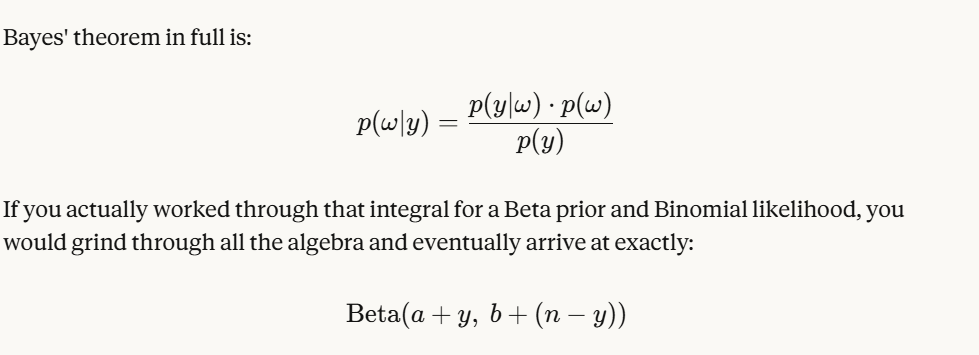

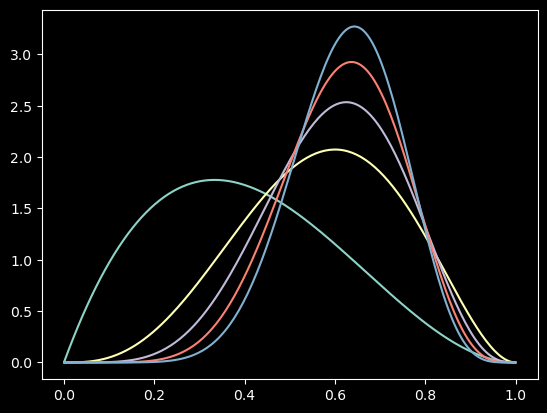

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta

# ── Setup ──────────────────────────────────────────────────────────────────────
N_OBS   = 20  # number of observations
PRIOR_A = 2
PRIOR_B = 3
Y_VALUES = [2, 6, 10, 14, 18]
COLORS   = ["#e63946", "#f69342", "#2a9d8f", "#457b9d", "#9b5de5"]

omega = np.linspace(0.001, 0.999, 500)

prior       = beta(PRIOR_A, PRIOR_B)
prior_mean  = prior.mean()
prior_var   = prior.var()

# i see more  daata. a gets 2 more observations! 
# so this is actually bayes therom!! it has just all been worked out Bayes' theorem in full is:

So when you write:
post =  beta(PRIOR_A+ 2, PRIOR_B)
post2 = beta(PRIOR_A+ 4, PRIOR_B +1)
post3 = beta(PRIOR_A+ 6, PRIOR_B +2)
post4 = beta(PRIOR_A+ 8, PRIOR_B +3)

omega = np.linspace(0.001, 0.999, 200)

prior = beta(PRIOR_A, PRIOR_B)

plt.plot(omega, [prior.pdf(x) for x in omega])
plt.plot(omega, [post.pdf(x) for x in omega])
plt.plot(omega, [post2.pdf(x) for x in omega])
plt.plot(omega, [post3.pdf(x) for x in omega])
plt.plot(omega, [post4.pdf(x) for x in omega])

In the binomial example with the uniform prior distribution, the prior mean is 1
2 , and
the prior variance is 1
12 . The posterior mean, y+1
n+2 , is a compromise between the prior mean
and the sample proportion, y
n , where clearly the prior mean has a smaller and smaller role
as the size of the data sample increases. This is a general feature of Bayesian inference: the
posterior distribution is centered at a point that represents a compromise between the prior
information and the data, and the compromise is controlled to a greater extent by the data
as the sample size increases.

0.4460285132382892
0.015854343318208036


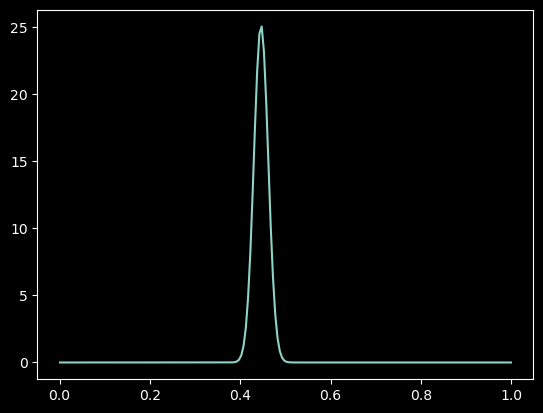

In [105]:
posterior= beta(438, 544)
plt.plot(omega, [posterior.pdf(x) for x in omega])
print(posterior.mean())
print(posterior.std())

Example. Probability of a girl birth given placenta previa
As a specific example of a factor that may influence the sex ratio, we consider the
maternal condition placenta previa, an unusual condition of pregnancy in which the
placenta is implanted low in the uterus, obstructing the fetus from a normal vaginal
delivery. An early study concerning the sex of placenta previa births in Germany found
that of a total of 980 births, 437 were female. How much evidence does this provide
for the claim that the proportion of female births in the population of placenta previa
births is less than 0.485, the proportion of female births in the general population?
Analysis using a uniform prior distribution. Under a uniform prior distribution for
the probability of a girl birth, the posterior distribution is Beta(438, 544). Exact
summaries of the posterior distribution can be obtained from the properties of the
beta distribution (Appendix A): the posterior mean of ω is 0.446 and the posterior
standard deviation is 0.016. Exact posterior quantiles can be obtained using numerical
integration of the beta density, which in practice we perform by a computer function
call; the median is 0.446 and the central 95% posterior interval is [0.415, 0.477]. This
95% posterior interval matches, to three decimal places, the interval that would be
obtained by using a normal approximation with the calculated posterior mean and
standard deviation. Further discussion of the approximate normality of the posterior
distribution is given in Chapter 4.
In many situations it is not feasible to perform calculations on the posterior density
function directly. In such cases it can be particularly useful to use simulation from the
posterior distribution to obtain inferences. The first histogram in Figure 2.3 shows the
distribution of 1000 draws from the Beta(438, 544) posterior distribution. An estimate
of the 95% posterior interval, obtained by taking the 25th and 976th of the 1000
ordered draws, is [0.415, 0.476], and the median of the 1000 draws from the posterior
distribution is 0.446. The sample mean and standard deviation of the 1000 draws are
0.445 and 0.016, almost identical to the exact results. A normal approximation to the
95% posterior interval is [0.445 ± 1.96 · 0.016] = [0.414, 0.476]. Because of the large
sample and the fact that the distribution of ω is concentrated away from zero and one,
the normal approximation works well in this example.
As already noted, when estimating a proportion, the normal approximation is generally improved by applying it to the logit transform, log( θ
1→θ ), which transforms the
parameter space from the unit interval to the real line. The second histogram in Figure
2.3 shows the distribution of the transformed draws. The estimated posterior mean
and standard deviation on the logit scale based on 1000 draws are −0.220 and 0.065.
A normal approximation to the 95% posterior int

In [101]:
prior.mean()

0.4

In [100]:
np.mean([post.mean(), post2.mean(),post3.mean() , post4.mean()])


0.6029532967032967

In [ ]:
# the prior mean of ω is the average of all possible posterior means over the distribution of possible data
# the varience of the prior is equal to the mean (of the varience of the posterier + the vairence of the posterior means)
#The variance formula (2.8)
#is more interesting because it says that the posterior variance is on average smaller than
#the prior variance, by an amount that depends on the variation in posterior means over
#the distribution of possible data. The greater the latter variation, the more the potential
#for reducing our uncertainty with regard to ω, as we shall see in detail for the binomial
#and normal models in the next chapter. 

Normal distribution lives on the entire normal line. 

A Beta distribution is a randsom variable, where the variable itself is a probability, so it HAS to be between 0-1.
But here's the subtle bit — the y-axis
For any PDF, the height is not probability. It's probability density. This trips everyone up.
You cannot say "the probability that x = 3.5 is 0.4". The probability of any exact single value is actually zero.
What the height tells you is — probability per unit width. To get actual probability you must integrate over an interval:


A Normal distribution the x axis can be anything



Beta disribution
Beta is a conjugate prior distribution for binomial probability. 
non informative densities, a= b =1

A conjugate prior is a Bayesian statistical concept where the chosen prior distribution and the resulting posterior distribution belong to the same probability distribution family. This mathematical convenience ensures the posterior can be computed analytically without complex numerical integration. Key examples include using a Beta distribution for binomial likelihoods or a Normal distribution for normal likelihoods
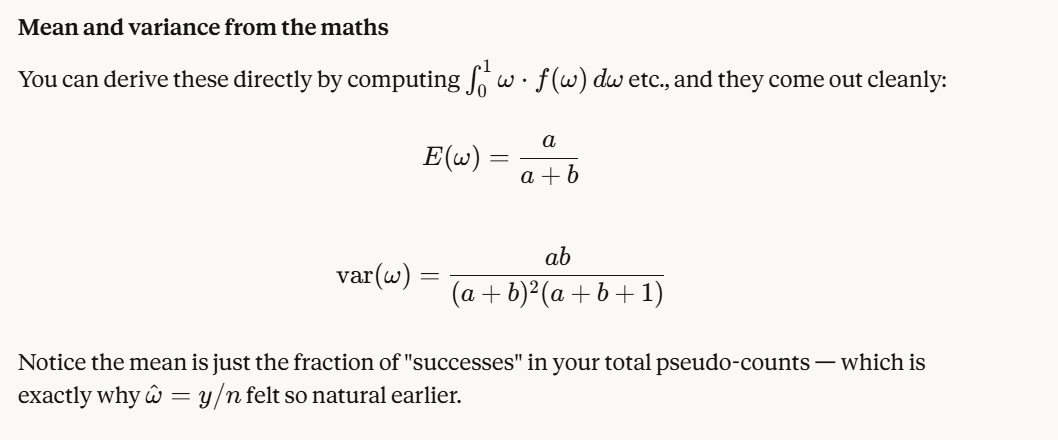

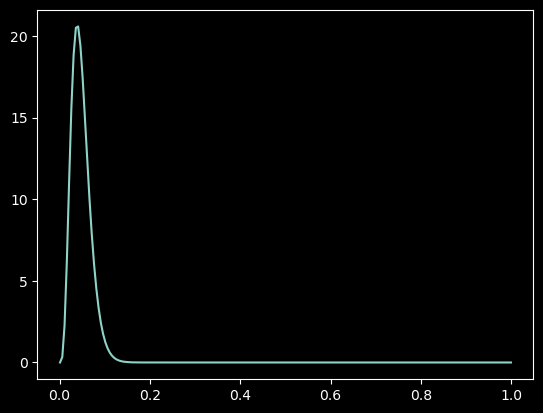

In [85]:
PRIOR_A = 5
PRIOR_B = 100

omega = np.linspace(0.001, 0.999, 200)

prior       = beta(PRIOR_A, PRIOR_B)

plt.plot(omega, [prior.pdf(x) for x in omega])

In [83]:
# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
BG      = "#0d1117"
PANEL   = "#161b22"
BORDER  = "#30363d"
MUTED   = "#8b949e"
WHITE   = "#e6edf3"
GREEN   = "#2a9d8f"
PURPLE  = "#9b5de5"
ORANGE  = "#f4a261"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_title(title, color=MUTED, fontsize=9,
                 loc="left", pad=8, fontfamily="monospace")
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

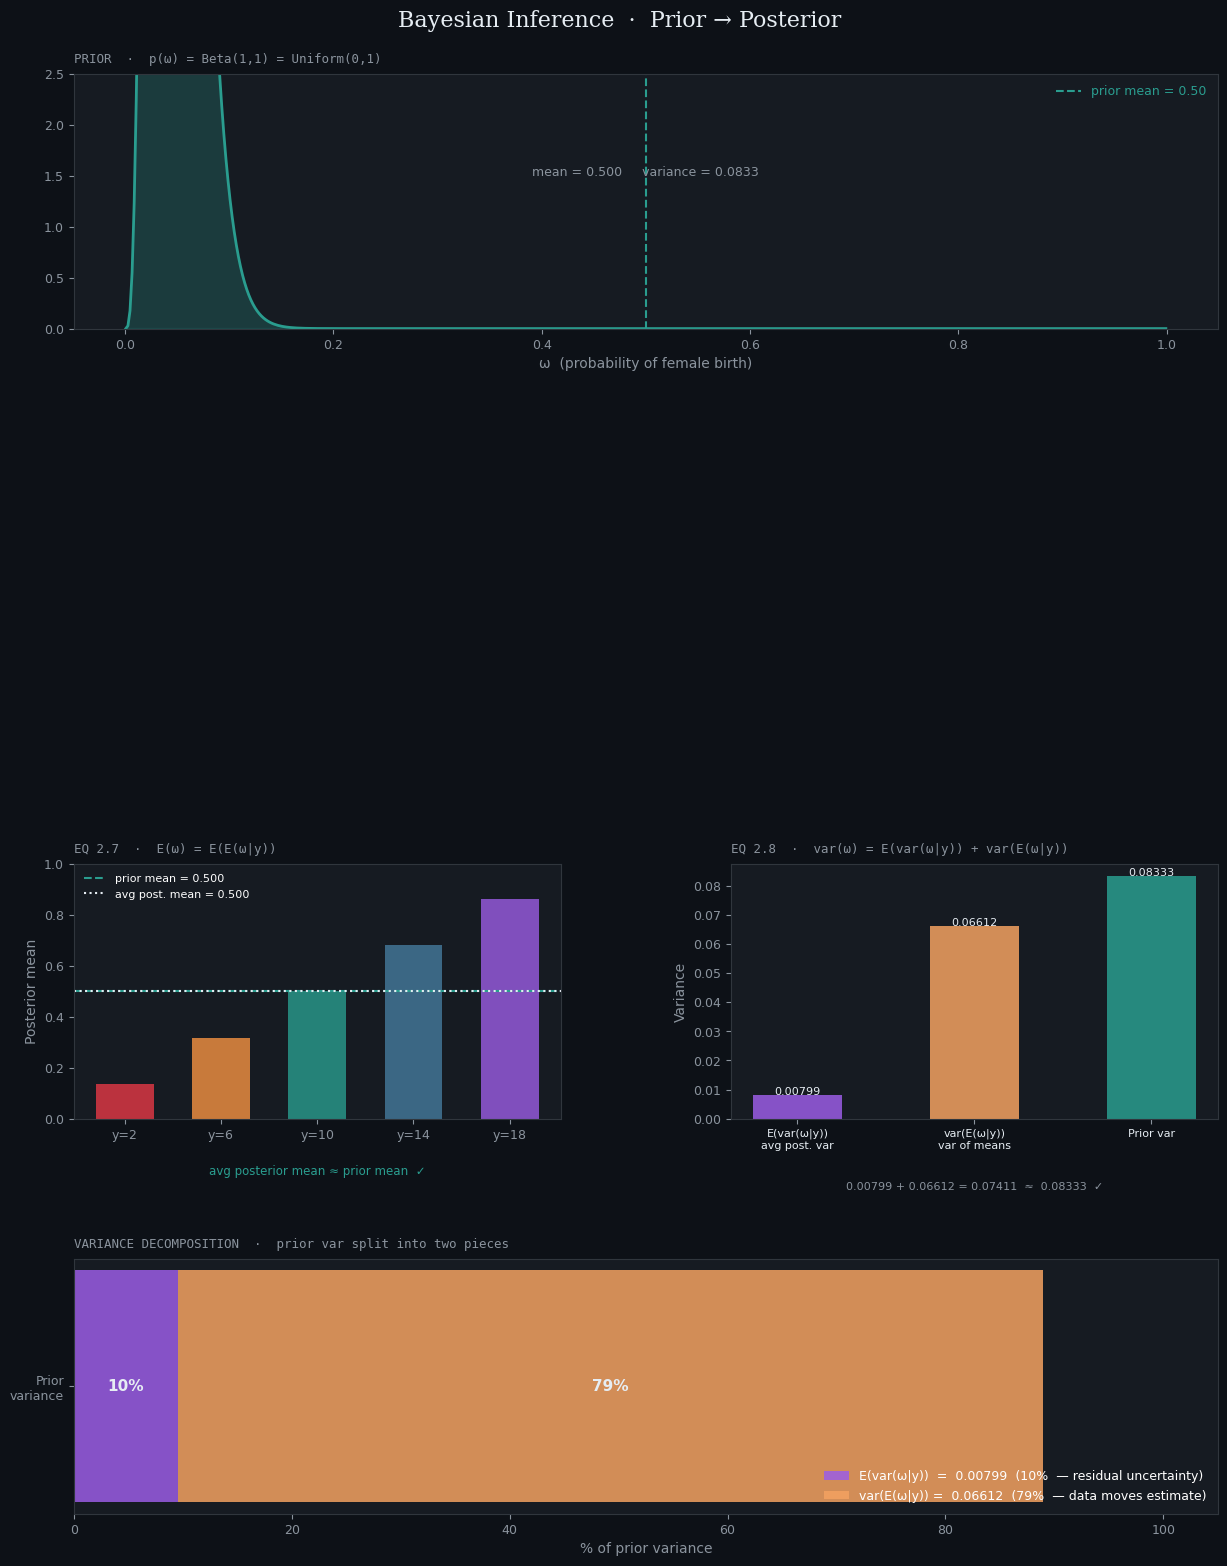

In [ ]:
fig = plt.figure(figsize=(13, 16), facecolor=BG)
fig.suptitle("Bayesian Inference  ·  Prior → Posterior",
             fontsize=16, color=WHITE, y=0.98, fontfamily="serif")

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.08, right=0.96, top=0.94, bottom=0.04)

# ── 1. Prior ───────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, "PRIOR  ·  p(ω) = Beta(1,1) = Uniform(0,1)")
y_prior = prior.pdf(omega)
ax1.fill_between(omega, y_prior, alpha=0.25, color=GREEN)
ax1.plot(omega, y_prior, color=GREEN, lw=2)
ax1.axvline(prior_mean, color=GREEN, ls="--", lw=1.5,
            label=f"prior mean = {prior_mean:.2f}")
ax1.set_ylim(0, 2.5)
ax1.set_xlabel("ω  (probability of female birth)")
ax1.legend(fontsize=9, framealpha=0, labelcolor=GREEN)
ax1.text(0.5, 0.6,
         f"mean = {prior_mean:.3f}     variance = {prior_var:.4f}",
         transform=ax1.transAxes, ha="center", color=MUTED, fontsize=9)

# ── 3. Eq 2.7 — bar of posterior means ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
style_ax(ax3, "EQ 2.7  ·  E(ω) = E(E(ω|y))")
means = [p["mean"] for p in posteriors]
cols  = [p["color"] for p in posteriors]
bars  = ax3.bar([f"y={p['y']}" for p in posteriors], means,
                color=cols, alpha=0.8, width=0.6)
ax3.axhline(prior_mean, color=GREEN, ls="--", lw=1.5,
            label=f"prior mean = {prior_mean:.3f}")
ax3.axhline(avg_post_mean, color=WHITE, ls=":", lw=1.5,
            label=f"avg post. mean = {avg_post_mean:.3f}")
ax3.set_ylim(0, 1)
ax3.set_ylabel("Posterior mean")
ax3.legend(fontsize=8, framealpha=0)
ax3.text(0.5, -0.22,
         "avg posterior mean ≈ prior mean  ✓",
         transform=ax3.transAxes, ha="center", color=GREEN, fontsize=8.5)

# ── 4. Eq 2.8 — variance decomposition ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
style_ax(ax4, "EQ 2.8  ·  var(ω) = E(var(ω|y)) + var(E(ω|y))")

labels  = ["E(var(ω|y))\navg post. var", "var(E(ω|y))\nvar of means", "Prior var"]
values  = [avg_post_var, var_post_means, prior_var]
bar_col = [PURPLE, ORANGE, GREEN]
x = np.arange(len(labels))
ax4.bar(x, values, color=bar_col, alpha=0.85, width=0.5)
ax4.set_xticks(x)
ax4.set_xticklabels(labels, fontsize=8, color=WHITE)
for xi, v in zip(x, values):
    ax4.text(xi, v + 0.0002, f"{v:.5f}", ha="center", color=WHITE, fontsize=8)
ax4.set_ylabel("Variance")
ax4.text(0.5, -0.28,
         f"{avg_post_var:.5f} + {var_post_means:.5f} = {avg_post_var+var_post_means:.5f}  ≈  {prior_var:.5f}  ✓",
         transform=ax4.transAxes, ha="center", color=MUTED, fontsize=8)

# ── 5. Stacked variance bar ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, :])
style_ax(ax5, "VARIANCE DECOMPOSITION  ·  prior var split into two pieces")
pct1 = avg_post_var   / prior_var * 100
pct2 = var_post_means / prior_var * 100
ax5.barh(["Prior\nvariance"], [pct1], color=PURPLE, alpha=0.85,
         label=f"E(var(ω|y))  =  {avg_post_var:.5f}  ({pct1:.0f}%  — residual uncertainty)")
ax5.barh(["Prior\nvariance"], [pct2], left=[pct1], color=ORANGE, alpha=0.85,
         label=f"var(E(ω|y)) =  {var_post_means:.5f}  ({pct2:.0f}%  — data moves estimate)")
ax5.set_xlim(0, 105)
ax5.set_xlabel("% of prior variance")
ax5.legend(fontsize=9, framealpha=0, loc="lower right")
ax5.text(pct1/2,        0, f"{pct1:.0f}%", va="center", ha="center",
         color=WHITE, fontsize=11, fontweight="bold")
ax5.text(pct1 + pct2/2, 0, f"{pct2:.0f}%", va="center", ha="center",
         color=WHITE, fontsize=11, fontweight="bold")


plt.show()


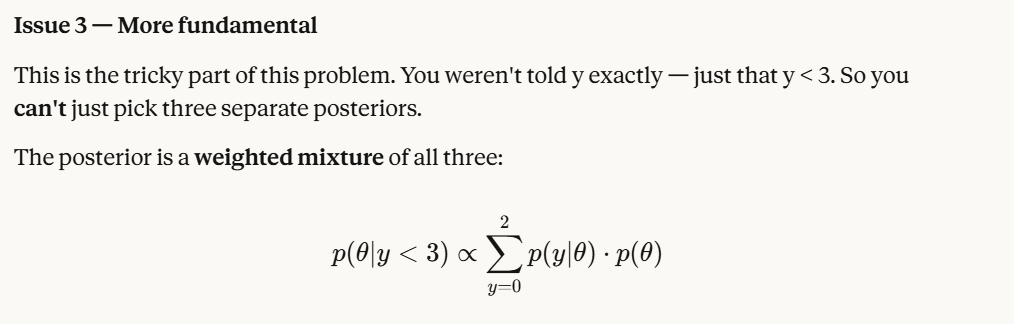

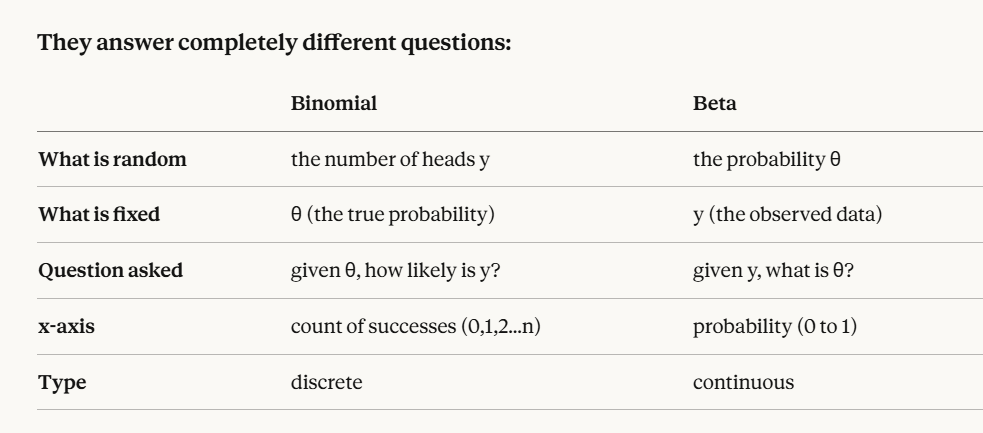

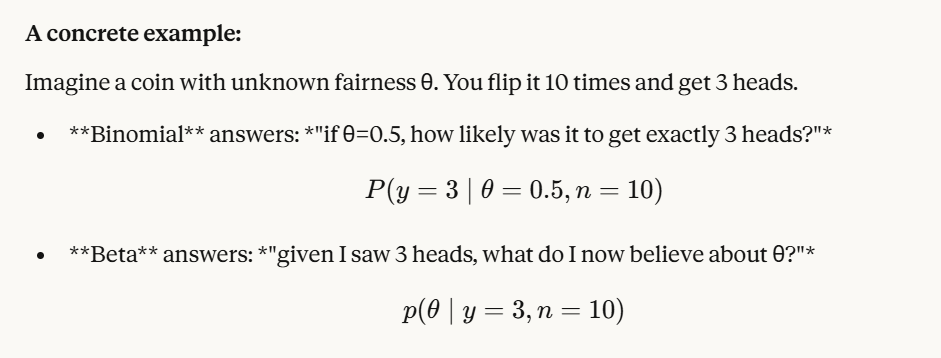

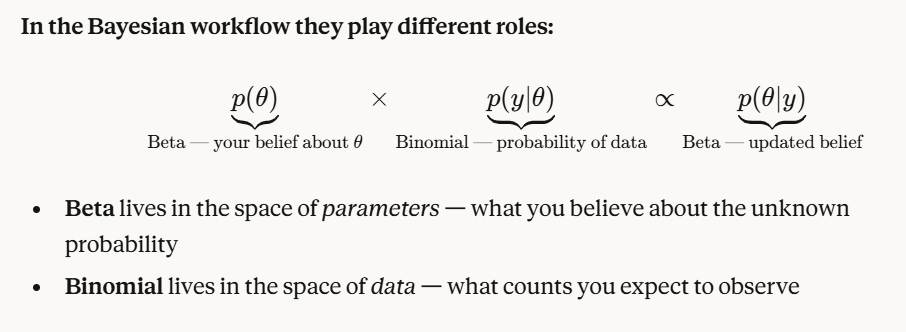

One sentence summary:

Binomial tells you about counts given a probability. Beta tells you about a probability given counts.

They're two sides of the same coin — literally.

11 Exercises
2.1 Posterior inference: suppose you have a Beta(4, 4) prior distribution on the probability θ
that a coin will yield a ‘head’ when spun in a specified manner. The coin is independently
spun ten times, and ‘heads’ appear fewer than 3 times. You are not told how many heads
were seen, only that the number is less than 3. Calculate your exact posterior density
(up to a proportionality constant) for θ and sketch it.

posterior. probabilityy( y<3 > given theta) = 

probability(theta given y<3>) = sum from 0 -2 of probability(y given theta)* probability(theta)

A pharmaceutical company is testing a new drug. They believe from previous studies that the probability of the drug curing a patient is somewhere around 0.7, but they're not very certain — they'd say their prior belief is roughly equivalent to having seen 7 cures out of 10 patients previously.
In a new clinical trial, 120 patients are treated. The trial is run in two separate hospitals:

Hospital A reports 38 cures out of 60 patients
Hospital B reports 51 cures out of 60 patients

Part 1 — Write down the prior distribution
Part 2 — Write down the likelihood for each hospital
Part 3 — What is the posterior after Hospital A's data?
Part 4 — Hospital B's results then come in. What is the final posterior using all data? Does it matter that the results came in separately rather than together?


2 = 
1) poisson?
2a) binom.pmf(38, n=60, p=0.7)
2b) binom.pmf(51, n=60, p=0.7)

2) prob( theta |y = 38 ) =prob(y | theta = 0.7) prob(theta)
prior = theta = 0.7. beta. 

y 38/60

b 

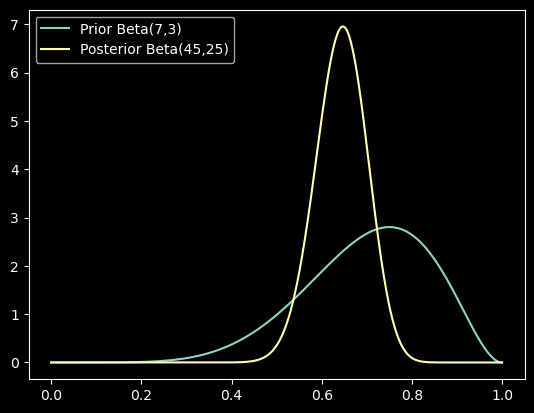

In [122]:

theta = np.linspace(0, 1, 500)

prior     = beta(7, 3)
posterior = beta(45, 25)   # Beta(7+38, 3+22)

plt.plot(theta, prior.pdf(theta),     label="Prior Beta(7,3)")
plt.plot(theta, posterior.pdf(theta), label="Posterior Beta(45,25)")
plt.legend()

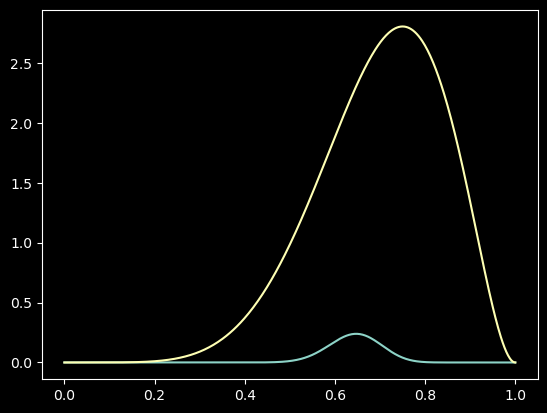

In [ ]:
# likelihood as a function of theta
def likelihood_A(theta):
    return binom.pmf(38, n=60, p=theta)

def update(theta):
    prior_density = beta(7,3).pdf(theta)
    return likelihood_A(theta) * prior_density

theta = np.linspace(0, 1, 500)
posterior_values = [update(t) for t in theta] 
plt.plot( theta, posterior_values)
plt.plot( theta, [beta(7,3).pdf(x) for x in theta])

In [112]:
beta(3,10)

In [ ]:
prob( theta |y = 38 ) =prob(y | theta ) prob(theta)

In [111]:
binom.pmf(38, n=60, p=0.7)

0.05771396497129114

Posterior inference: suppose you have a Beta(4, 4) prior distribution on the probability ω
that a coin will yield a ‘head’ when spun in a specified manner. The coin is independently
spun ten times, and ‘heads’ appear fewer than 3 times. You are not told how many heads
were seen, only that the number is less than 3. Calculate your exact posterior density
(up to a proportionality constant) for ω and sketch it.

unknown, theta = head. beta dist. 
data y < 3
prior = beta(4,4)

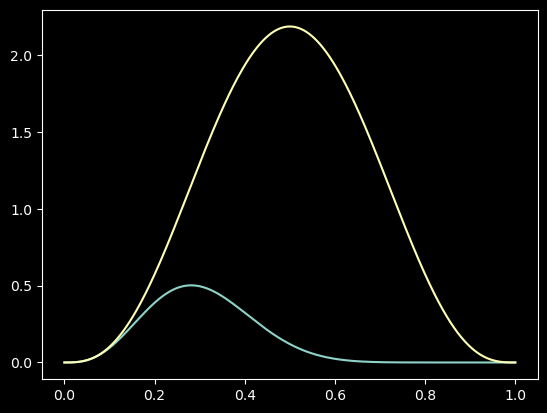

In [ ]:
from scipy.stats import binom



prior = beta(4,4)
n = 10
obvs=  [0, 1,2]

theta = np.linspace(0, 1, 500)
#The conjugate shortcut only works when you know y exactly.
# posterior is proportional to this at each θ
def posterior_density(theta):
    likelihood = sum(binom.pmf(y, n=10, p=theta) for y in [0,1,2])
    prior_density = beta(4,4).pdf(theta)
    return likelihood * prior_density

plt.plot(theta, [posterior_density(x) for x in theta] )
plt.plot(theta, [beta(4,4).pdf(x) for x in theta])

 Predictive distributions: consider two coins, C1 and C2, with the following characteristics:
Pr(heads|C1) = 0.6 and Pr(heads|C2) = 0.4. Choose one of the coins at random and
imagine spinning it repeatedly. Given that the first two spins from the chosen coin are
tails, what is the expectation of the number of additional spins until a head shows up?

P(heads|C1|y, n) binomial, with y chance of success = 1

expectiation, sum of the value * prob

sum of 0,1,2,3,4.... * prob (y)

binomial dist.
P()

P(success)

Expected y

probabilaty

In [ ]:
binom.pmf(k=0, n = 3, p=0.6)  #prob first 2 are tails

0.06400000000000003

In [ ]:
binom.pmf(k=2, n = 3, p=0.6)  #pmf exat proabability of a disccreate function

0.43199999999999994

In [ ]:

def expected(p):
    spins = [0,1,2,3,4,5,6,7,8,9,10,11,12,13]
    ex_val = []
    first_two = binom.pmf(k=2, n = 3, p=p)
    for additional_spins in spins:
        ex_val.append(binom.pmf(k=1, n = additional_spins, p=p)* additional_spins*first_two)

    sum(ex_val)
    return sum(ex_val)


In [147]:
0.5*expected(0.6)+ 0.5*(expected(0.4))

2.2337965202669574

2.3 Predictive distributions: let y be the number of 6’s in 1000 rolls of a fair die.
(a) Sketch the approximate distribution of y, based on the normal approximation.
(b) Using the normal distribution table, give approximate 5%, 25%, 50%, 75%, and 95%
points for the distribution of y.



In [ ]:
mu = 1/6 * 1000 # if n is large and close to 0.5 

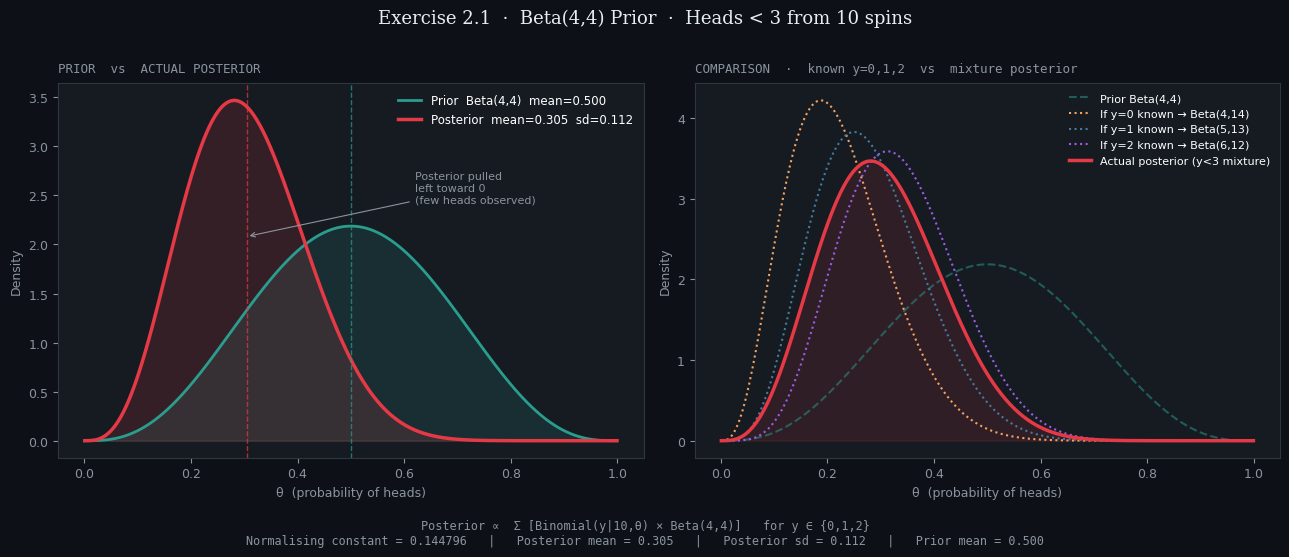

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom
from scipy.integrate import quad

# ── Setup ──────────────────────────────────────────────────────────────────────
n       = 10
prior   = beta(4, 4)
theta   = np.linspace(0.001, 0.999, 500)

# ── Densities ──────────────────────────────────────────────────────────────────

# Prior
prior_pdf = prior.pdf(theta)

# Individual posteriors if we KNEW y exactly (for comparison)
individual = {
    y: beta(4 + y, 4 + (n - y)).pdf(theta)
    for y in [0, 1, 2]
}

# Actual posterior — mixture weighted by likelihood
def unnorm_posterior(t):
    likelihood = sum(binom.pmf(y, n=n, p=t) for y in [0, 1, 2])
    return likelihood * prior.pdf(t)

unnorm = np.array([unnorm_posterior(t) for t in theta])

# Normalise so it integrates to 1
norm_const, _ = quad(unnorm_posterior, 0, 1)
posterior_pdf  = unnorm / norm_const

# ── Stats ──────────────────────────────────────────────────────────────────────
post_mean = quad(lambda t: t * unnorm_posterior(t), 0, 1)[0] / norm_const
post_var  = quad(lambda t: (t**2) * unnorm_posterior(t), 0, 1)[0] / norm_const - post_mean**2
post_sd   = np.sqrt(post_var)
prior_mean = prior.mean()

# ── Style ──────────────────────────────────────────────────────────────────────
BG, PANEL, BORDER = "#0d1117", "#161b22", "#30363d"
MUTED, WHITE      = "#8b949e", "#e6edf3"
GREEN, RED        = "#2a9d8f", "#e63946"
COLORS            = ["#f4a261", "#457b9d", "#9b5de5"]

plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle("Exercise 2.1  ·  Beta(4,4) Prior  ·  Heads < 3 from 10 spins",
             fontsize=13, color=WHITE, fontfamily="serif", y=1.01)

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_title(title, color=MUTED, fontsize=9, loc="left", pad=8, fontfamily="monospace")
    ax.set_xlabel("θ  (probability of heads)", color=MUTED, fontsize=9)
    ax.set_ylabel("Density", color=MUTED, fontsize=9)

# ── Left plot: Prior vs Posterior ──────────────────────────────────────────────
ax = axes[0]
style_ax(ax, "PRIOR  vs  ACTUAL POSTERIOR")

ax.fill_between(theta, prior_pdf,    alpha=0.15, color=GREEN)
ax.fill_between(theta, posterior_pdf, alpha=0.15, color=RED)
ax.plot(theta, prior_pdf,     color=GREEN, lw=2,   label=f"Prior  Beta(4,4)  mean={prior_mean:.3f}")
ax.plot(theta, posterior_pdf, color=RED,   lw=2.5, label=f"Posterior  mean={post_mean:.3f}  sd={post_sd:.3f}")

ax.axvline(prior_mean, color=GREEN, ls="--", lw=1, alpha=0.7)
ax.axvline(post_mean,  color=RED,   ls="--", lw=1, alpha=0.7)

ax.legend(fontsize=8.5, framealpha=0, loc="upper right")

# annotation
ax.annotate(f"Posterior pulled\nleft toward 0\n(few heads observed)",
            xy=(post_mean, posterior_pdf.max()*0.6),
            xytext=(0.62, posterior_pdf.max()*0.7),
            color=MUTED, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))

# ── Right plot: what if we KNEW y ─────────────────────────────────────────────
ax2 = axes[1]
style_ax(ax2, "COMPARISON  ·  known y=0,1,2  vs  mixture posterior")

ax2.plot(theta, prior_pdf, color=GREEN, lw=1.5, ls="--", alpha=0.5, label="Prior Beta(4,4)")

for i, (y, pdf) in enumerate(individual.items()):
    a, b = 4+y, 4+(n-y)
    ax2.plot(theta, pdf, color=COLORS[i], lw=1.5, ls=":",
             label=f"If y={y} known → Beta({a},{b})")

ax2.plot(theta, posterior_pdf, color=RED, lw=2.5,
         label=f"Actual posterior (y<3 mixture)")
ax2.fill_between(theta, posterior_pdf, alpha=0.12, color=RED)

ax2.legend(fontsize=8, framealpha=0, loc="upper right")

# ── Text box ──────────────────────────────────────────────────────────────────
fig.text(0.5, -0.06,
    f"Posterior ∝  Σ [Binomial(y|10,θ) × Beta(4,4)]   for y ∈ {{0,1,2}}\n"
    f"Normalising constant = {norm_const:.6f}   |   "
    f"Posterior mean = {post_mean:.3f}   |   "
    f"Posterior sd = {post_sd:.3f}   |   "
    f"Prior mean = {prior_mean:.3f}",
    ha="center", color=MUTED, fontsize=8.5, fontfamily="monospace")

plt.tight_layout()
plt.show()

beta distribution is a distribution of a variable with two outcomes, bernouli. has spread 

Chapter 3. 
Have points x and y , have lots of values of intecept and slope. we can use posterior draws to numerically calculate distribution. sampling based appraoch. posteriory drawers. theta (s) we have many s, theta include both slope andintercempt. approximate expectations. 

Margainal distribution of a  subset or collection of random variables is the probability distribution of the cariables contrained in the subset.Ultimate goal is to obtain a marginal posteror distrubution of a parameter of interest. first get the JOINT posterior of all unknowns, integrate the distribution over the unknowns that are NOT of immediate interest, obtain the desired marhginal distribution. in many problems there is no interest in making inferences about many of the unknown  parameterd, although they are required inorder to construct a realistic model. Paremeters of this kind are often called nuisance paramters. a classic example is the example of random errors in ameasruement problem.


TypeError: rv_frozen.cdf() missing 1 required positional argument: 'x'

In [74]:
prior = beta(PRIOR_A, PRIOR_B)
prior.pdf()

TypeError: rv_continuous_frozen.pdf() missing 1 required positional argument: 'x'